In [44]:
import numpy as np
import sklearn
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import imageio.v3 as iio
import os
from PIL import Image
import imagehash
import shutil
from sklearn.model_selection import train_test_split


# Data loading and Processing

In [45]:
Image_size = 96
Batch = 32
Random_seed = 42

In [46]:
def remove_duplicates_smart(paths, labels, class_to_idx):
    unique_hashes = {}
    clean_paths, clean_labels = [], []
    # Identify the specific index for No_Fire to treat it differently
    no_fire_idx = class_to_idx.get('No_Fire', 2) 
    
    print(f"Initial files: {len(paths)}")
    for p, l in zip(paths, labels):
        try:
            with Image.open(p) as img:
                # We use a higher hash size for No_Fire to be more precise
                hash_size = 16 if l == no_fire_idx else 8 
                h = str(imagehash.phash(img, hash_size=hash_size))
                
                if h not in unique_hashes:
                    unique_hashes[h] = p
                    clean_paths.append(p)
                    clean_labels.append(l)
                elif l == no_fire_idx:
                    # SAFETY NET: If it's No_Fire, keep it even if hash matches
                    # This prevents shrinking your smallest class further
                    clean_paths.append(p)
                    clean_labels.append(l)
        except Exception:
            continue
            
    print(f"After smart dedup: {len(clean_paths)}")
    return clean_paths, clean_labels

# STEP 1: Collect all paths + labels
all_p, all_l = [], []
base_dir = "Training_Tri/"
class_names = sorted(os.listdir(base_dir))
class_to_idx = {name: i for i, name in enumerate(class_names)}

for class_name in class_names:
    c_path = os.path.join(base_dir, class_name)
    if not os.path.isdir(c_path): continue
    files = [os.path.join(c_path, f) for f in os.listdir(c_path)]
    all_p.extend(files)
    all_l.extend([class_to_idx[class_name]] * len(files))

# STEP 2: Use the Smart Deduplication
all_p_clean, all_l_clean = remove_duplicates_smart(all_p, all_l, class_to_idx)

# STEP 3: Split the clean pool
tr_p, temp_p, tr_l, temp_l = train_test_split(
    all_p_clean, all_l_clean, test_size=0.3, random_state=Random_seed, stratify=all_l_clean
)
val_p, te_p, val_l, te_l = train_test_split(
    temp_p, temp_l, test_size=0.5, random_state=Random_seed, stratify=temp_l
)

print(f"Split sizes -> Train: {len(tr_p)} | Val: {len(val_p)} | Test: {len(te_p)}")

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [Image_size, Image_size])
    return img, label

Initial files: 39375
After smart dedup: 10344
Split sizes -> Train: 7240 | Val: 1552 | Test: 1552


In [47]:
def check_leakage_by_class(tr_p, tr_l, te_p, te_l):
    train_hashes = {}
    for p, l in zip(tr_p, tr_l):
        with Image.open(p) as img:
            h = str(imagehash.phash(img))
            train_hashes[h] = l

    for cls in np.unique(te_l):
        cls_paths = [p for p, l in zip(te_p, te_l) if l == cls]
        leak = 0
        for p in cls_paths:
            with Image.open(p) as img:
                h = str(imagehash.phash(img))
                if h in train_hashes:
                    leak += 1
        print(f"Class {cls}: {leak}/{len(cls_paths)} leaked ({100*leak/len(cls_paths):.1f}%)")

check_leakage_by_class(tr_p, tr_l, te_p, te_l)

Class 0: 0/774 leaked (0.0%)
Class 1: 0/401 leaked (0.0%)
Class 2: 217/377 leaked (57.6%)


In [48]:
def focal_loss_sparse(gamma, alpha):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        
        # One-hot encode y_true
        y_true_one_hot = tf.one_hot(y_true, depth=y_pred.shape[-1])
        
        # Cross entropy
        ce = -tf.reduce_sum(y_true_one_hot * tf.math.log(y_pred), axis=-1)
        
        # Focal weight
        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        focal_weight = alpha * tf.pow(1 - p_t, gamma)
        
        return tf.reduce_mean(focal_weight * ce)
    return loss

def apply_blur(img):
    img = tf.expand_dims(img, 0)  
    img = tf.nn.avg_pool2d(img, ksize=3, strides=1, padding='SAME')
    return tf.squeeze(img, 0) 

def augment(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))    
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.6)
    image = tf.image.random_hue(image, max_delta=0.05)

    # Haze
    haze_intensity = tf.random.uniform((), 0.05, 0.25)
    haze = tf.ones_like(image) * 0.7
    image = tf.cond(
        tf.random.uniform(()) > 0.5,
        lambda: image * (1 - haze_intensity) + haze * haze_intensity,
        lambda: image
    )

    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def compute_class_weights_Tri(ds):
    labels = np.concatenate([y.numpy() for _, y in ds.batch(512)])    
    classes = np.unique(labels)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels)
    class_weights = dict(zip(classes, weights))
    print(f"Class weights: {class_weights}")
    return class_weights

In [49]:
train_ds = (
    tf.data.Dataset.from_tensor_slices((tr_p, tr_l))
    .shuffle(len(tr_p), seed=Random_seed)
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_p, val_l))
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((te_p, te_l))
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

# For class weights, build a plain dataset from tr_p/tr_l (no augment)
train_raw_for_weights = (
    tf.data.Dataset.from_tensor_slices((tr_p, tr_l))
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
)
class_weights = compute_class_weights_Tri(train_raw_for_weights)

Class weights: {0: 0.6686986238108432, 1: 1.287797936677339, 2: 1.3735534054259153}


In [50]:

model = keras.models.Sequential([
    
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
    
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
   
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.3),
   
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(3, activation='softmax')
])



model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=focal_loss_sparse(gamma=2.0, alpha=0.5),  # use what you wrote
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',  # something that actually exists
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        'best_fire_model.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min'
    )
]

history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    class_weight= class_weights,
    callbacks=callbacks
)

Epoch 1/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4710 - loss: 0.2293 - val_accuracy: 0.4987 - val_loss: 0.2195 - learning_rate: 1.0000e-04
Epoch 2/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6113 - loss: 0.1680 - val_accuracy: 0.7126 - val_loss: 0.1213 - learning_rate: 1.0000e-04
Epoch 3/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7120 - loss: 0.1020 - val_accuracy: 0.7635 - val_loss: 0.0893 - learning_rate: 1.0000e-04
Epoch 4/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7228 - loss: 0.0931 - val_accuracy: 0.7925 - val_loss: 0.0717 - learning_rate: 1.0000e-04
Epoch 5/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7186 - loss: 0.0912 - val_accuracy: 0.7706 - val_loss: 0.0785 - learning_rate: 1.0000e-04
Epoch 6/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7293 - loss: 0.0859 - val_accuracy: 0.6063 - val_loss: 0.0727 - learning_rate: 1.0000e-04
Epoch 7/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - acc

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. POPULATE THE DATA (The missing step)
true_labels = []
y_pred_prob = []

print("Running model on test data...")
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    true_labels.extend(labels.numpy())
    y_pred_prob.extend(preds)

true_labels = np.array(true_labels)
y_pred_prob = np.array(y_pred_prob)

# 2. APPLY THRESHOLD LOGIC
# We raise the bar for Fire and Lake. If the model isn't 85% sure, 
# it defaults to No_Fire (Class 2).
# Try lower thresholds to see where the model's confidence actually sits
FIRE_THRESHOLD = 0.5
LAKE_THRESHOLD = 0.5

final_preds = []
for prob in y_pred_prob:
    if prob[0] > FIRE_THRESHOLD:
        final_preds.append(0)
    elif prob[1] > LAKE_THRESHOLD:
        final_preds.append(1)
    else:
        final_preds.append(2)
        
final_preds = np.array(final_preds)

# 3. PRINT ACCURATE RESULTS
print("\nAdjusted Classification Report:")
# Assuming your classes are 0: Fire, 1: Lake, 2: No_Fire based on your folder structure
print(classification_report(true_labels, final_preds, target_names=['Fire', 'Lake', 'No_Fire']))

print("\nAdjusted Confusion Matrix:")
print(confusion_matrix(true_labels, final_preds))


Running model on test data...

Adjusted Classification Report:
              precision    recall  f1-score   support

        Fire       0.82      0.76      0.79       774
        Lake       0.99      1.00      0.99       401
     No_Fire       0.57      0.66      0.61       377

    accuracy                           0.79      1552
   macro avg       0.79      0.80      0.80      1552
weighted avg       0.80      0.79      0.80      1552


Adjusted Confusion Matrix:
[[586   0 188]
 [  0 400   1]
 [125   5 247]]


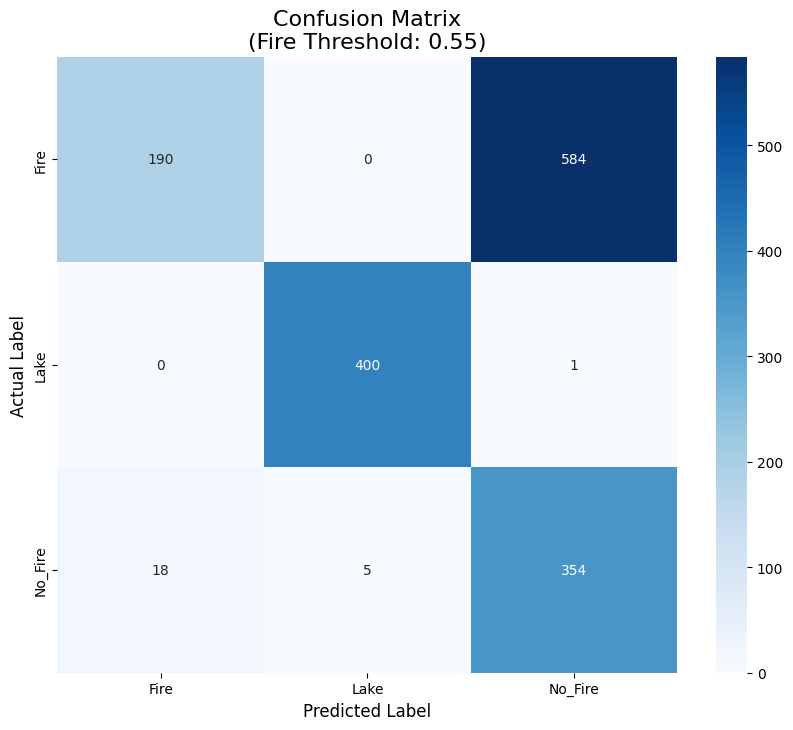

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate the confusion matrix using your final_preds
cm = confusion_matrix(true_labels, final_preds)

# 2. Set up the figure
plt.figure(figsize=(10, 8))

# 3. Create the heatmap
sns.heatmap(
    cm, 
    annot=True,          # Put the numbers in the boxes
    fmt='d',             # Use integers instead of scientific notation
    cmap='Blues',        # Color theme
    xticklabels=['Fire', 'Lake', 'No_Fire'], 
    yticklabels=['Fire', 'Lake', 'No_Fire']
)

# 4. Add labels and title
plt.title(f'Confusion Matrix\n(Fire Threshold: {FIRE_THRESHOLD})', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

In [53]:
# Try a list of thresholds to see the effect on No_Fire Recall
for t in [0.40, 0.45, 0.5, 0.55]:
    test_preds = []
    for prob in y_pred_prob:
        if prob[0] > t: # Fire
            test_preds.append(0)
        elif prob[1] > 0.90: # Lake
            test_preds.append(1)
        else:
            test_preds.append(2) # No_Fire
            
    report = classification_report(true_labels, test_preds, output_dict=True, target_names=['Fire', 'Lake', 'No_Fire'])
    print(f"Threshold {t} -> No_Fire Recall: {report['No_Fire']['recall']:.2f} | Fire Precision: {report['Fire']['precision']:.2f}")

Threshold 0.4 -> No_Fire Recall: 0.23 | Fire Precision: 0.72
Threshold 0.45 -> No_Fire Recall: 0.46 | Fire Precision: 0.78
Threshold 0.5 -> No_Fire Recall: 0.67 | Fire Precision: 0.82
Threshold 0.55 -> No_Fire Recall: 0.95 | Fire Precision: 0.91


In [54]:
def check_leakage_by_class(tr_p, tr_l, te_p, te_l):
    train_hashes = {}
    for p, l in zip(tr_p, tr_l):
        with Image.open(p) as img:
            h = str(imagehash.phash(img))
            train_hashes[h] = l

    for cls in np.unique(te_l):
        cls_paths = [p for p, l in zip(te_p, te_l) if l == cls]
        leak = 0
        for p in cls_paths:
            with Image.open(p) as img:
                h = str(imagehash.phash(img))
                if h in train_hashes:
                    leak += 1
        print(f"Class {cls}: {leak}/{len(cls_paths)} leaked ({100*leak/len(cls_paths):.1f}%)")

check_leakage_by_class(tr_p, tr_l, te_p, te_l)

Class 0: 0/774 leaked (0.0%)
Class 1: 0/401 leaked (0.0%)
Class 2: 217/377 leaked (57.6%)


In [55]:
def build_fire_model_scaled(model_size='medium', loss_fn=None):
    scales = {
        'very_small': (2, 4, 8),   
        'small':      (3, 8, 12),  
        'medium':     (4, 8, 16),  
        'large':      (4, 16, 64), 
        'very_large': (5, 32, 128) 
    }
    num_blocks, base_filters, dense_dim = scales[model_size]
    
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(96, 96, 3)))

    for i in range(num_blocks):
        filters = base_filters * (2**i)
        model.add(keras.layers.Conv2D(filters, 3, activation='relu', padding='same'))
        model.add(keras.layers.Conv2D(filters, 3, activation='relu', padding='same'))
        model.add(keras.layers.MaxPooling2D())
        model.add(keras.layers.Dropout(0.2 if i < 2 else 0.3))

    model.add(keras.layers.Conv2D(filters * 2, 3, activation='relu', padding='same'))
    model.add(keras.layers.GlobalAveragePooling2D())
    model.add(keras.layers.Dense(dense_dim, activation='relu'))
    model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=loss_fn,
        metrics=['accuracy'] # Removed precision/recall here to prevent Shape/Key Errors
    )
    return model

def run_experiment(size, loss_func, weights, callbacks):
    print(f"\n--- TESTING {size.upper()} ---")
    model = build_fire_model_scaled(size, loss_func)
    history = model.fit(train_ds, validation_data=val_ds, epochs=30, 
                        class_weight=weights, callbacks=callbacks, verbose=1)
    
    # Plotting only the metrics that exist
    metrics = ['loss', 'accuracy'] 
    plt.figure(figsize=(12, 5))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.plot(history.history[metric], label='Train')
        plt.plot(history.history[f'val_{metric}'], label='Val')
        plt.title(f'{size} {metric}')
        plt.legend()
    plt.show()
    return model, history


--- TESTING VERY_SMALL ---
Epoch 1/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.4985 - loss: 0.2298 - val_accuracy: 0.4987 - val_loss: 0.2160 - learning_rate: 1.0000e-04
Epoch 2/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4979 - loss: 0.2102 - val_accuracy: 0.4987 - val_loss: 0.1853 - learning_rate: 1.0000e-04
Epoch 3/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6269 - loss: 0.1813 - val_accuracy: 0.7487 - val_loss: 0.1510 - learning_rate: 1.0000e-04
Epoch 4/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6959 - loss: 0.1534 - val_accuracy: 0.7564 - val_loss: 0.1140 - learning_rate: 1.0000e-04
Epoch 5/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7051 - loss: 0.1276 - val_accuracy: 0.7577 - val_loss: 0.0883 - learning_rate: 1.0000e-04
Epoch 6/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7144 - loss: 0.1091 - val_accuracy: 0.7577 - val_loss: 0.0764 - learning_rate: 1.0000e-04
Epoch 7/30
227/227 ━━━━━━━━━━━━

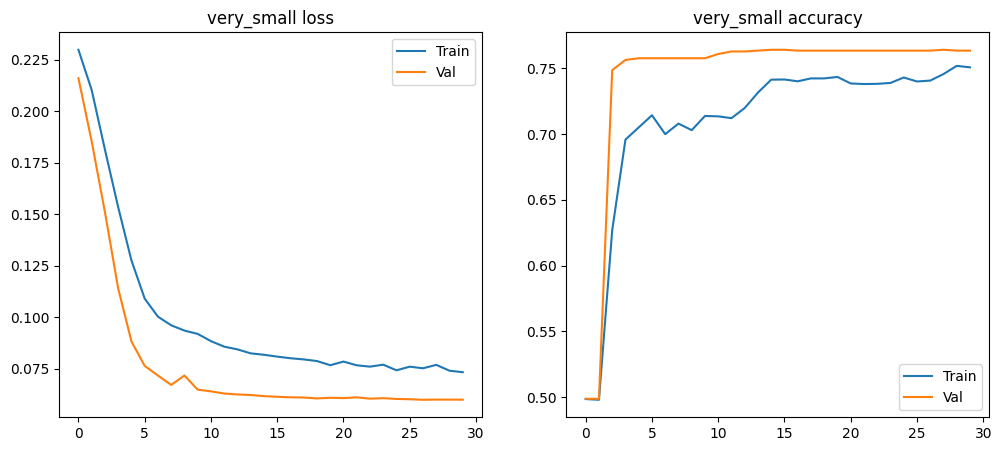


--- TESTING SMALL ---
Epoch 1/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.4990 - loss: 0.2119 - val_accuracy: 0.7558 - val_loss: 0.1560 - learning_rate: 1.0000e-04
Epoch 2/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.6605 - loss: 0.1310 - val_accuracy: 0.7577 - val_loss: 0.0853 - learning_rate: 1.0000e-04
Epoch 3/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.7035 - loss: 0.0995 - val_accuracy: 0.7577 - val_loss: 0.0717 - learning_rate: 1.0000e-04
Epoch 4/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.7206 - loss: 0.0909 - val_accuracy: 0.7603 - val_loss: 0.0668 - learning_rate: 5.0000e-05
Epoch 5/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.7177 - loss: 0.0876 - val_accuracy: 0.7635 - val_loss: 0.0660 - learning_rate: 5.0000e-05


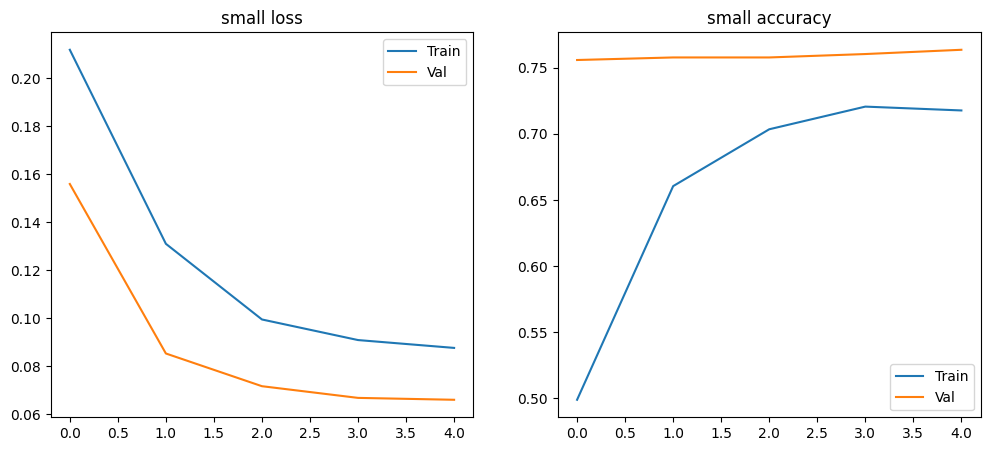


--- TESTING MEDIUM ---
Epoch 1/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.5414 - loss: 0.1896 - val_accuracy: 0.6302 - val_loss: 0.1767 - learning_rate: 1.0000e-04
Epoch 2/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.6858 - loss: 0.0950 - val_accuracy: 0.6585 - val_loss: 0.1610 - learning_rate: 1.0000e-04
Epoch 3/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.6874 - loss: 0.0851 - val_accuracy: 0.6836 - val_loss: 0.1345 - learning_rate: 1.0000e-04
Epoch 4/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7006 - loss: 0.0798 - val_accuracy: 0.7229 - val_loss: 0.0947 - learning_rate: 5.0000e-05
Epoch 5/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7093 - loss: 0.0787 - val_accuracy: 0.7519 - val_loss: 0.0792 - learning_rate: 5.0000e-05


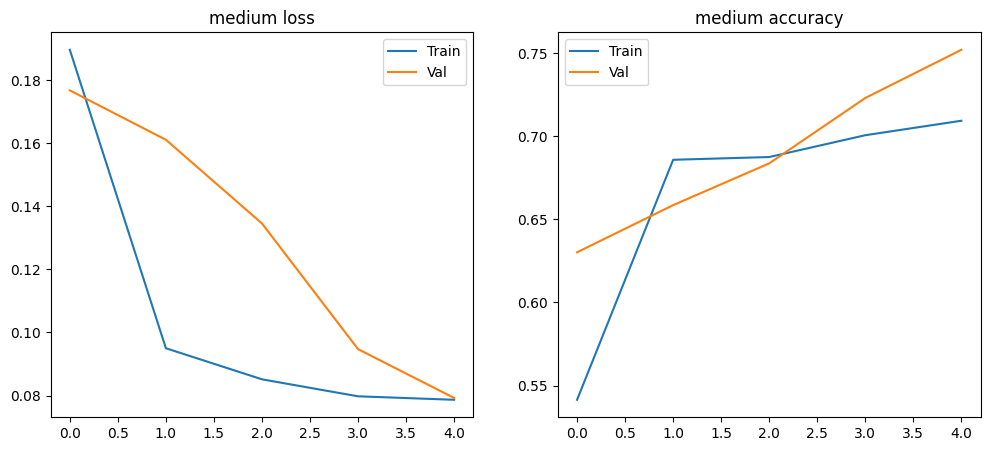


--- TESTING LARGE ---
Epoch 1/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.5811 - loss: 0.1635 - val_accuracy: 0.6501 - val_loss: 0.1844 - learning_rate: 1.0000e-04
Epoch 2/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.7312 - loss: 0.0821 - val_accuracy: 0.6952 - val_loss: 0.1415 - learning_rate: 1.0000e-04
Epoch 3/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.7533 - loss: 0.0765 - val_accuracy: 0.6791 - val_loss: 0.1626 - learning_rate: 1.0000e-04
Epoch 4/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.7606 - loss: 0.0733 - val_accuracy: 0.7120 - val_loss: 0.1325 - learning_rate: 5.0000e-05
Epoch 5/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.7631 - loss: 0.0709 - val_accuracy: 0.7416 - val_loss: 0.1079 - learning_rate: 5.0000e-05


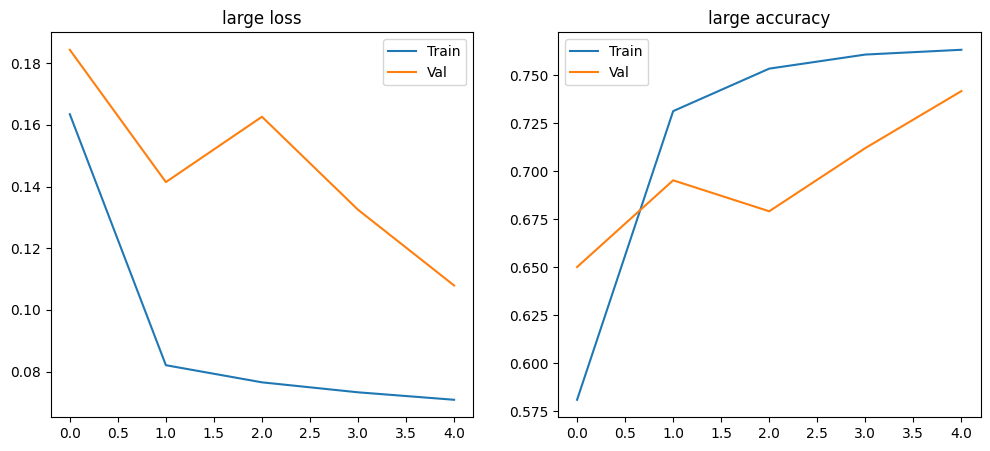

In [56]:
# Configure your variables
focal_loss = focal_loss_sparse(gamma=2.0, alpha=0.5)
my_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

# Run the test
all_results = {}
for model_size in ['very_small', 'small', 'medium', 'large']:
    all_results[model_size] = run_experiment(model_size, focal_loss, class_weights, my_callbacks)

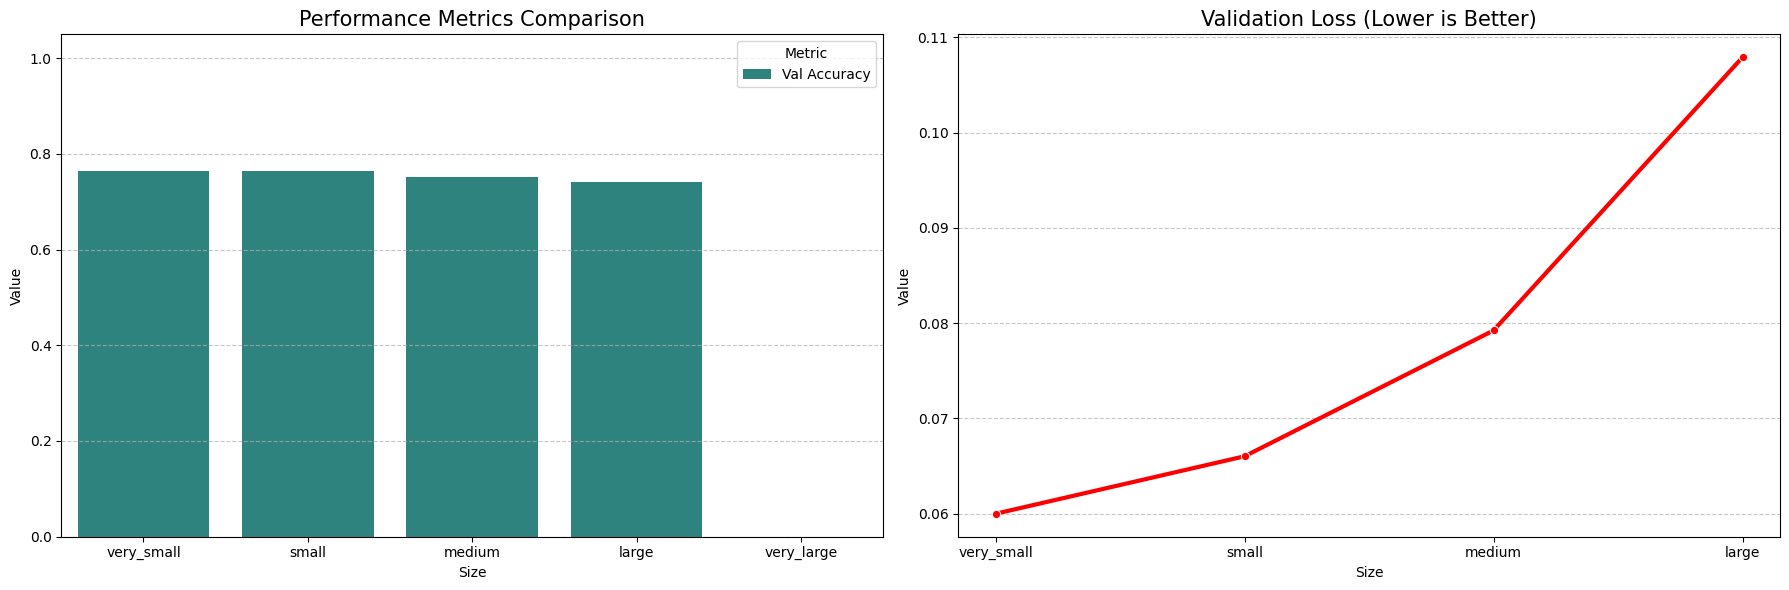

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_model_comparison(results_dict):
    # 1. Extract final metrics from each history object
    data = []
    for size, history in results_dict.items():
        # Get the index of the best val_loss (best model)
        best_epoch = np.argmin(history.history['val_loss'])
        
        row = {
            'Size': size,
            'Val Accuracy': history.history['val_accuracy'][best_epoch],
            'Val Loss': history.history['val_loss'][best_epoch],
        }
        # Add precision/recall if they exist (for Binary)
        if 'val_precision' in history.history:
            row['Val Precision'] = history.history['val_precision'][best_epoch]
            row['Val Recall'] = history.history['val_recall'][best_epoch]
            
        data.append(row)

    df = pd.DataFrame(data)
    
    # Define the order for the X-axis
    order = ['very_small', 'small', 'medium', 'large', 'very_large']
    df['Size'] = pd.Categorical(df['Size'], categories=order, ordered=True)
    df = df.sort_values('Size')

    # 2. Create the "Pretty" Plot
    # We use a long-form format for Seaborn
    df_melted = df.melt(id_vars='Size', var_name='Metric', value_name='Value')
    
    # Separate Loss from other metrics for better scale
    df_metrics = df_melted[df_melted['Metric'] != 'Val Loss']
    df_loss = df_melted[df_melted['Metric'] == 'Val Loss']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Left Plot: Accuracy/Precision/Recall
    sns.barplot(data=df_metrics, x='Size', y='Value', hue='Metric', ax=ax1, palette='viridis')
    ax1.set_title('Performance Metrics Comparison', fontsize=15)
    ax1.set_ylim(0, 1.05)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Right Plot: Loss (Lower is better)
    sns.lineplot(data=df_loss, x='Size', y='Value', marker='o', ax=ax2, color='red', linewidth=3)
    ax2.set_title('Validation Loss (Lower is Better)', fontsize=15)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# To run it:
# plot_model_comparison(all_results)
def plot_model_comparison(results_dict):
    data = []
    for size, result in results_dict.items():
        # 1. Handle the tuple (model, history)
        # In your run_experiment, index 0 is model, index 1 is history
        if isinstance(result, tuple):
            history_obj = result[1] 
        else:
            history_obj = result
        
        # 2. Extract the actual dictionary of metrics
        h = history_obj.history 
        
        # 3. Use 'h' (the dictionary) to find the best epoch
        best_epoch = np.argmin(h['val_loss'])
        
        row = {
            'Size': size,
            'Val Accuracy': h['val_accuracy'][best_epoch],
            'Val Loss': h['val_loss'][best_epoch],
        }
        
        # 4. Check for optional metrics using the dict 'h'
        if 'val_precision' in h:
            row['Val Precision'] = h['val_precision'][best_epoch]
            row['Val Recall'] = h['val_recall'][best_epoch]
            
        data.append(row)

    # --- Rest of your plotting code stays the same ---
    df = pd.DataFrame(data)
    order = ['very_small', 'small', 'medium', 'large', 'very_large']
    df['Size'] = pd.Categorical(df['Size'], categories=order, ordered=True)
    df = df.sort_values('Size')

    df_melted = df.melt(id_vars='Size', var_name='Metric', value_name='Value')
    df_metrics = df_melted[df_melted['Metric'] != 'Val Loss']
    df_loss = df_melted[df_melted['Metric'] == 'Val Loss']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    sns.barplot(data=df_metrics, x='Size', y='Value', hue='Metric', ax=ax1, palette='viridis')
    ax1.set_title('Performance Metrics Comparison', fontsize=15)
    ax1.set_ylim(0, 1.05)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    sns.lineplot(data=df_loss, x='Size', y='Value', marker='o', ax=ax2, color='red', linewidth=3)
    ax2.set_title('Validation Loss (Lower is Better)', fontsize=15)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
# To run it:
plot_model_comparison(all_results)

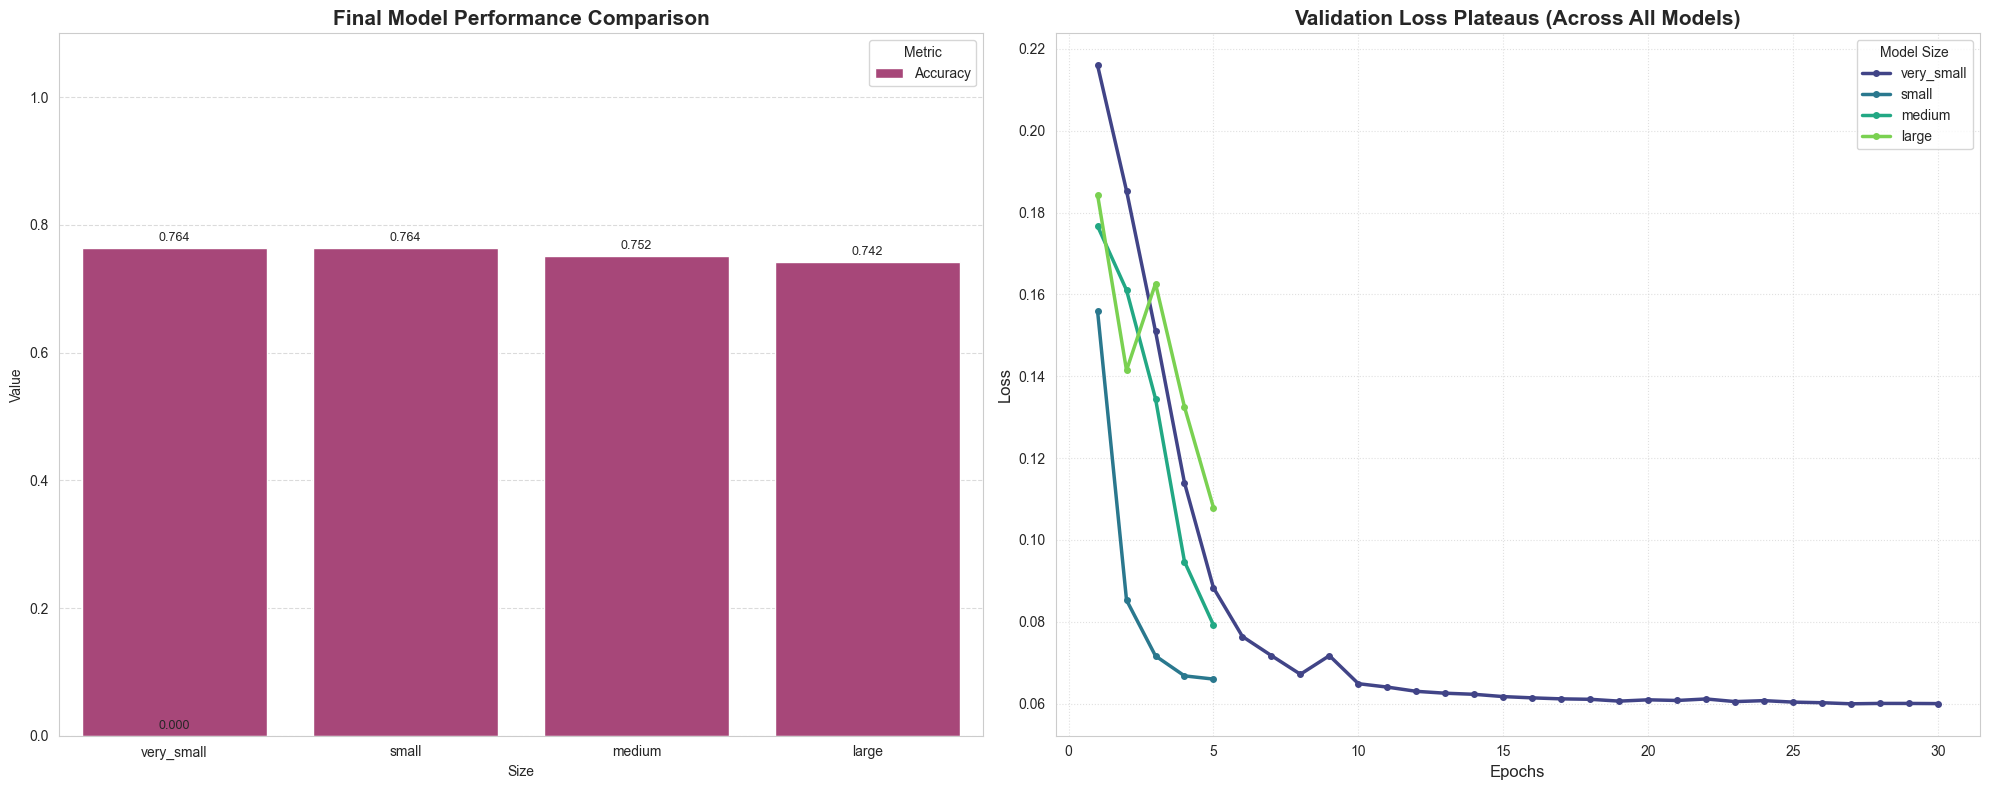

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_model_analysis(results_dict):
    # --- 1. DATA PROCESSING FOR BAR CHART ---
    data = []
    for size, result in results_dict.items():
        # Handle the (model, history) tuple from run_experiment
        history_obj = result[1] if isinstance(result, tuple) else result
        h = history_obj.history 
        
        # Find best epoch based on validation loss
        best_epoch = np.argmin(h['val_loss'])
        
        row = {
            'Size': size,
            'Accuracy': h['val_accuracy'][best_epoch],
        }
        # Add Precision/Recall if they exist in your compiled metrics
        if 'val_precision' in h: row['Precision'] = h['val_precision'][best_epoch]
        if 'val_recall' in h: row['Recall'] = h['val_recall'][best_epoch]
            
        data.append(row)

    df = pd.DataFrame(data)
    order = ['very_small', 'small', 'medium', 'large', 'very_large']
    existing_order = [o for o in order if o in df['Size'].unique()]
    df['Size'] = pd.Categorical(df['Size'], categories=existing_order, ordered=True)
    df = df.sort_values('Size')

    # --- 2. SETUP PLOTS ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    colors = sns.color_palette("viridis", len(df))

    # --- LEFT: BAR PLOT (Accuracy/Precision/Recall) ---
    df_melted = df.melt(id_vars='Size', var_name='Metric', value_name='Value')
    sns.barplot(data=df_melted, x='Size', y='Value', hue='Metric', ax=ax1, palette='magma')
    ax1.set_title('Final Model Performance Comparison', fontsize=15, fontweight='bold')
    ax1.set_ylim(0, 1.1)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add values on top of bars
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='baseline', fontsize=9, xytext=(0, 5), textcoords='offset points')

    # --- RIGHT: LINE PLOT (Loss Plateaus over Epochs) ---
    for (size, result), color in zip(results_dict.items(), colors):
        history_obj = result[1] if isinstance(result, tuple) else result
        h = history_obj.history
        epochs = range(1, len(h['val_loss']) + 1)
        
        # Plot Validation Loss for each model
        ax2.plot(epochs, h['val_loss'], label=f'{size}', linewidth=2.5, color=color, marker='o', markersize=4)

    ax2.set_title('Validation Loss Plateaus (Across All Models)', fontsize=15, fontweight='bold')
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(title='Model Size')
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Run the combined analysis
plot_model_analysis(all_results)